In [4]:
import zipfile
import os
import cv2
import random
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score
import seaborn as sns

zip_path = "/content/archive (21).zip"
extract_path = "extracted_images"

# Extract the ZIP file
with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

# Read all images
images = []

for root, dirs, files in os.walk(extract_path):
    for file in files:
        if file.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            img_path=os.path.join(root, file)
            img = cv2.imread(img_path)

            if img is not None:
                images.append(img)

print("Total images loaded:", len(images))

Total images loaded: 506


/tmp/ipykernel_1137/1908145513.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['No Tumor', 'Tumor'], y=counts, palette='pastel')


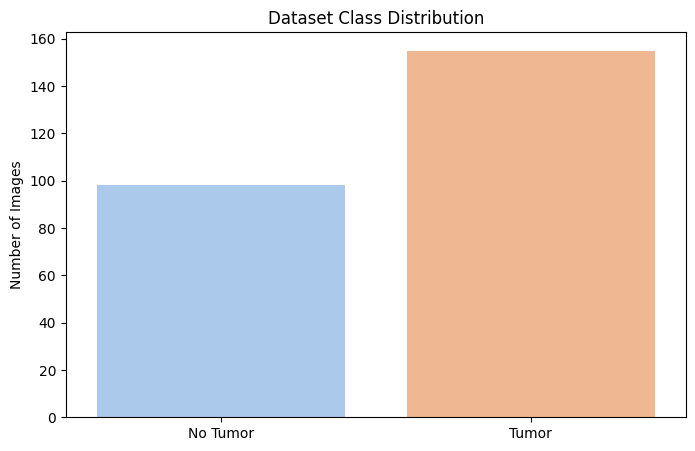

In [5]:
classes = ['no', 'yes']
folder_path = "extracted_images"

# --- 1. Class Distribution Bar Chart ---
counts = []
for c in classes:
    # Count how many files are in each folder
    num_images = len(os.listdir(os.path.join(folder_path, c)))
    counts.append(num_images)

plt.figure(figsize=(8, 5))
sns.barplot(x=['No Tumor', 'Tumor'], y=counts, palette='pastel')
plt.title('Dataset Class Distribution')
plt.ylabel('Number of Images')
plt.show()


Displaying Sample Images:


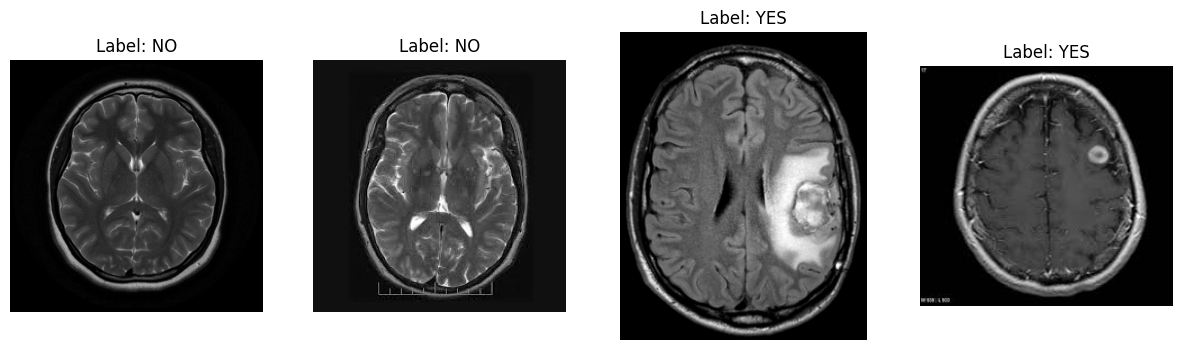

In [6]:
# --- 2. View Sample Images ---
print("\nDisplaying Sample Images:")
fig, axes = plt.subplots(1, 4, figsize=(15, 4))

# Pick 2 random 'no' images and 2 random 'yes' images
sample_classes = ['no', 'no', 'yes', 'yes']

for i, c in enumerate(sample_classes):
    class_folder = os.path.join(folder_path, c)
    random_file = random.choice(os.listdir(class_folder))

    # Read and convert color for Matplotlib
    img = cv2.imread(os.path.join(class_folder, random_file))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(f"Label: {c.upper()}")
    axes[i].axis('off')

plt.show()

In [7]:
import os
import cv2
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# --- 1. LOAD & FLATTEN ---
X = []
y = []
classes = ['no', 'yes'] # UPDATE THESE to match your actual folder names

print("Processing images...")
for label, category in enumerate(classes):
    folder_path = f"extracted_images/{category}"

    for file in os.listdir(folder_path):
        img = cv2.imread(os.path.join(folder_path, file), cv2.IMREAD_GRAYSCALE)
        if img is not None:
            # Resize to 64x64 and flatten into a 1D array immediately
            X.append(cv2.resize(img, (64, 64)).flatten())
            y.append(label)

# --- 2. TRAIN ---
print("Training the Random Forest model...")
# Convert lists to arrays and split the data (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(np.array(X), np.array(y), test_size=0.2)

# Initialize and train the model in two lines
model = RandomForestClassifier()
model.fit(X_train, y_train)

# --- 3. EVALUATE ---
predictions = model.predict(X_test)
print(f"Final Accuracy: {accuracy_score(y_test, predictions) * 100:.2f}%")

Processing images...
Training the Random Forest model...
Final Accuracy: 90.20%


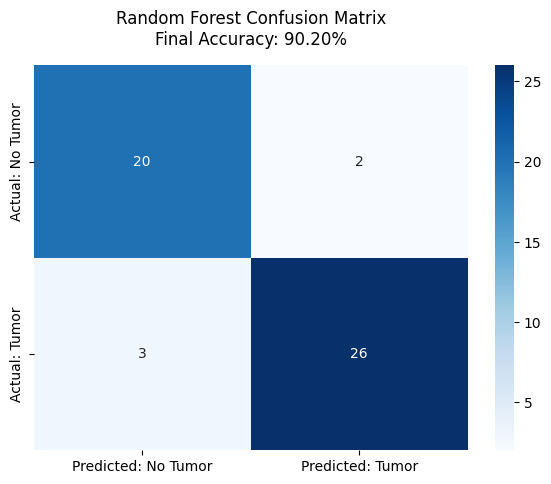

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix using your test data and predictions
cm = confusion_matrix(y_test, predictions)
acc = accuracy_score(y_test, predictions) * 100

# Plot the Confusion Matrix as a Heatmap
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted: No Tumor', 'Predicted: Tumor'],
            yticklabels=['Actual: No Tumor', 'Actual: Tumor'])

plt.title(f'Random Forest Confusion Matrix\nFinal Accuracy: {acc:.2f}%', pad=15)
plt.show()

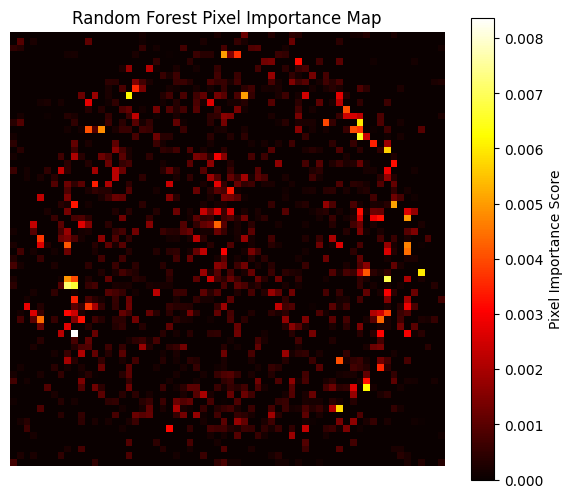

In [9]:
import numpy as np

# Get the importance of each pixel from the Random Forest
importances = model.feature_importances_

# Reshape the 1D array (4096,) back into a 2D image shape (64, 64)
importance_map = importances.reshape(64, 64)

# Plot the heatmap
plt.figure(figsize=(7, 6))
# Using 'hot' colormap: brighter colors mean the model relies heavily on that pixel
plt.imshow(importance_map, cmap='hot', interpolation='nearest')
plt.colorbar(label='Pixel Importance Score')
plt.title('Random Forest Pixel Importance Map')
plt.axis('off')
plt.show()

In [10]:
import joblib

# Save the model to a file
joblib.dump(model, 'brain_tumor_rf_model.pkl')
print("Model saved successfully!")

Model saved successfully!


In [11]:
# 1. Pick ONE image path from your extracted folders
test_image_path = "/content/extracted_images/yes/Y102.jpg" # UPDATE THIS LINE

# 2. Process it exactly like the training data
img=cv2.imread(test_image_path, cv2.IMREAD_GRAYSCALE)
img_resized=cv2.resize(img, (64, 64))

# reshape(1, -1) tells the model we are only predicting one single image
img_flattened=img_resized.flatten().reshape(1, -1)

# 3. Make the prediction
prediction=model.predict(img_flattened)

if prediction[0] == 1:
    print("Prediction: TUMOR DETECTED")
else:
    print("Prediction: NO TUMOR")

Prediction: TUMOR DETECTED
